# Wine Shop & Delicatessen — Exploratory Data Analysis

**Course:** Advanced Programming with Python — Session 3 (Visualization)  
**Case:** Data Mining Case Study — Wine shop & delicatessen

**Goal of the assignment:** identify customer behavior patterns from a survey of 404 customers so the store can deliver a more personalized service and rebalance its perception (currently seen more as a wine shop than a delicatessen).

**This notebook** is a first-pass EDA: every univariate, bivariate, and a few multivariate views of the data, kept simple so a *Run All* produces every chart without errors.

## Variables
| Column | Type | Notes |
|---|---|---|
| `ID` | int | survey respondent id |
| `Wine frequency consumption` | categorical | 6 levels |
| `Payment mode` | categorical | Cash / Credit / Debit |
| `Place to drink` | categorical | 7 levels |
| `Additional products` | categorical | 8 deli products |
| `Gender` | categorical | Male / Female |
| `Education` | categorical | 9+ levels (some dirty) |
| `Age` | categorical (bins) | 4 levels |
| `Ticket` | numeric (€) | basket value |

## 1. Setup & Load

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13

# Data lives at ../data/ relative to this notebook (notebooks/ → repo root → data/).
df = pd.read_excel('../data/wine_consumption_survey.xlsx', sheet_name='Hoja1')
print('Shape:', df.shape)
df.head()


## 2. Quick data quality check

In [2]:
print('--- dtypes ---')
print(df.dtypes)
print('\n--- missing ---')
print(df.isna().sum())
print('\n--- duplicates on ID ---', df['ID'].duplicated().sum())
df.describe(include='all').T

--- dtypes ---
ID                             int64
Wine frequency consumption       str
Payment mode                     str
Place to drink                   str
Additional products              str
Gender                           str
Education                     object
Age                              str
Ticket                         int64
dtype: object

--- missing ---
ID                            0
Wine frequency consumption    0
Payment mode                  0
Place to drink                0
Additional products           0
Gender                        0
Education                     0
Age                           0
Ticket                        0
dtype: int64

--- duplicates on ID --- 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,404.0,NaN,NaN,NaN,202.5,116.769003,1.0,101.75,202.5,303.25,404.0
Wine frequency consumption,404,6,1 to 2 times per week,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment mode,404,3,Cash,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Place to drink,404,7,Parties,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Additional products,404,8,Olives,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,404,2,Male,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,404,10,Universitary Degree,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,404,4,31 to 40,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket,404.0,NaN,NaN,NaN,55.69802,26.949966,10.0,32.75,56.5,79.0,100.0


In [3]:
# Light cleanup: there's a single odd Education value '1'. Coerce to NaN for plots.
df['Education'] = df['Education'].replace({1: np.nan, '1': np.nan})

# Order categoricals so charts read left-to-right naturally.
freq_order = ['Once per month', 'More than once per month',
              '1 to 2 times per week', '3 to 4 times per week',
              '5 to 6 times per week', 'Once per day']
age_order  = ['23 to 30', '31 to 40', '41 to 50', 'more than 50']
edu_order  = ['Primary', 'Secondary Unfinished', 'Secondary',
              'Technical Superior Unfinished', 'Technical Superior',
              'Universitary Degree Unfinished', 'Universitary Degree',
              'Postgraduate Unfinished', 'Postgraduate']

df['Wine frequency consumption'] = pd.Categorical(df['Wine frequency consumption'], categories=freq_order, ordered=True)
df['Age']       = pd.Categorical(df['Age'], categories=age_order, ordered=True)
df['Education'] = pd.Categorical(df['Education'], categories=edu_order, ordered=True)

cat_cols = ['Wine frequency consumption', 'Payment mode', 'Place to drink',
            'Additional products', 'Gender', 'Education', 'Age']
num_cols = ['Ticket']
df.head()

,ID,Wine frequency consumption,Payment mode,Place to drink,Additional products,Gender,Education,Age,Ticket
0,1,1 to 2 times per week,Debit card,Parties,Cheese,Male,NaN,31 to 40,66
1,5,1 to 2 times per week,Debit card,Parties,Olives,Female,Technical Superior,31 to 40,87
2,6,Once per month,Debit card,On holidays,Olives,Female,Universitary Degree,41 to 50,66
3,17,Once per month,Debit card,Friends home,Spanish ham,Female,NaN,31 to 40,65
4,25,Once per month,Debit card,On holidays,Chocolate,Male,Universitary Degree Unfinished,41 to 50,81


## 3. Univariate — Categorical features
Count of customers per category. Quick sense of which categories dominate.

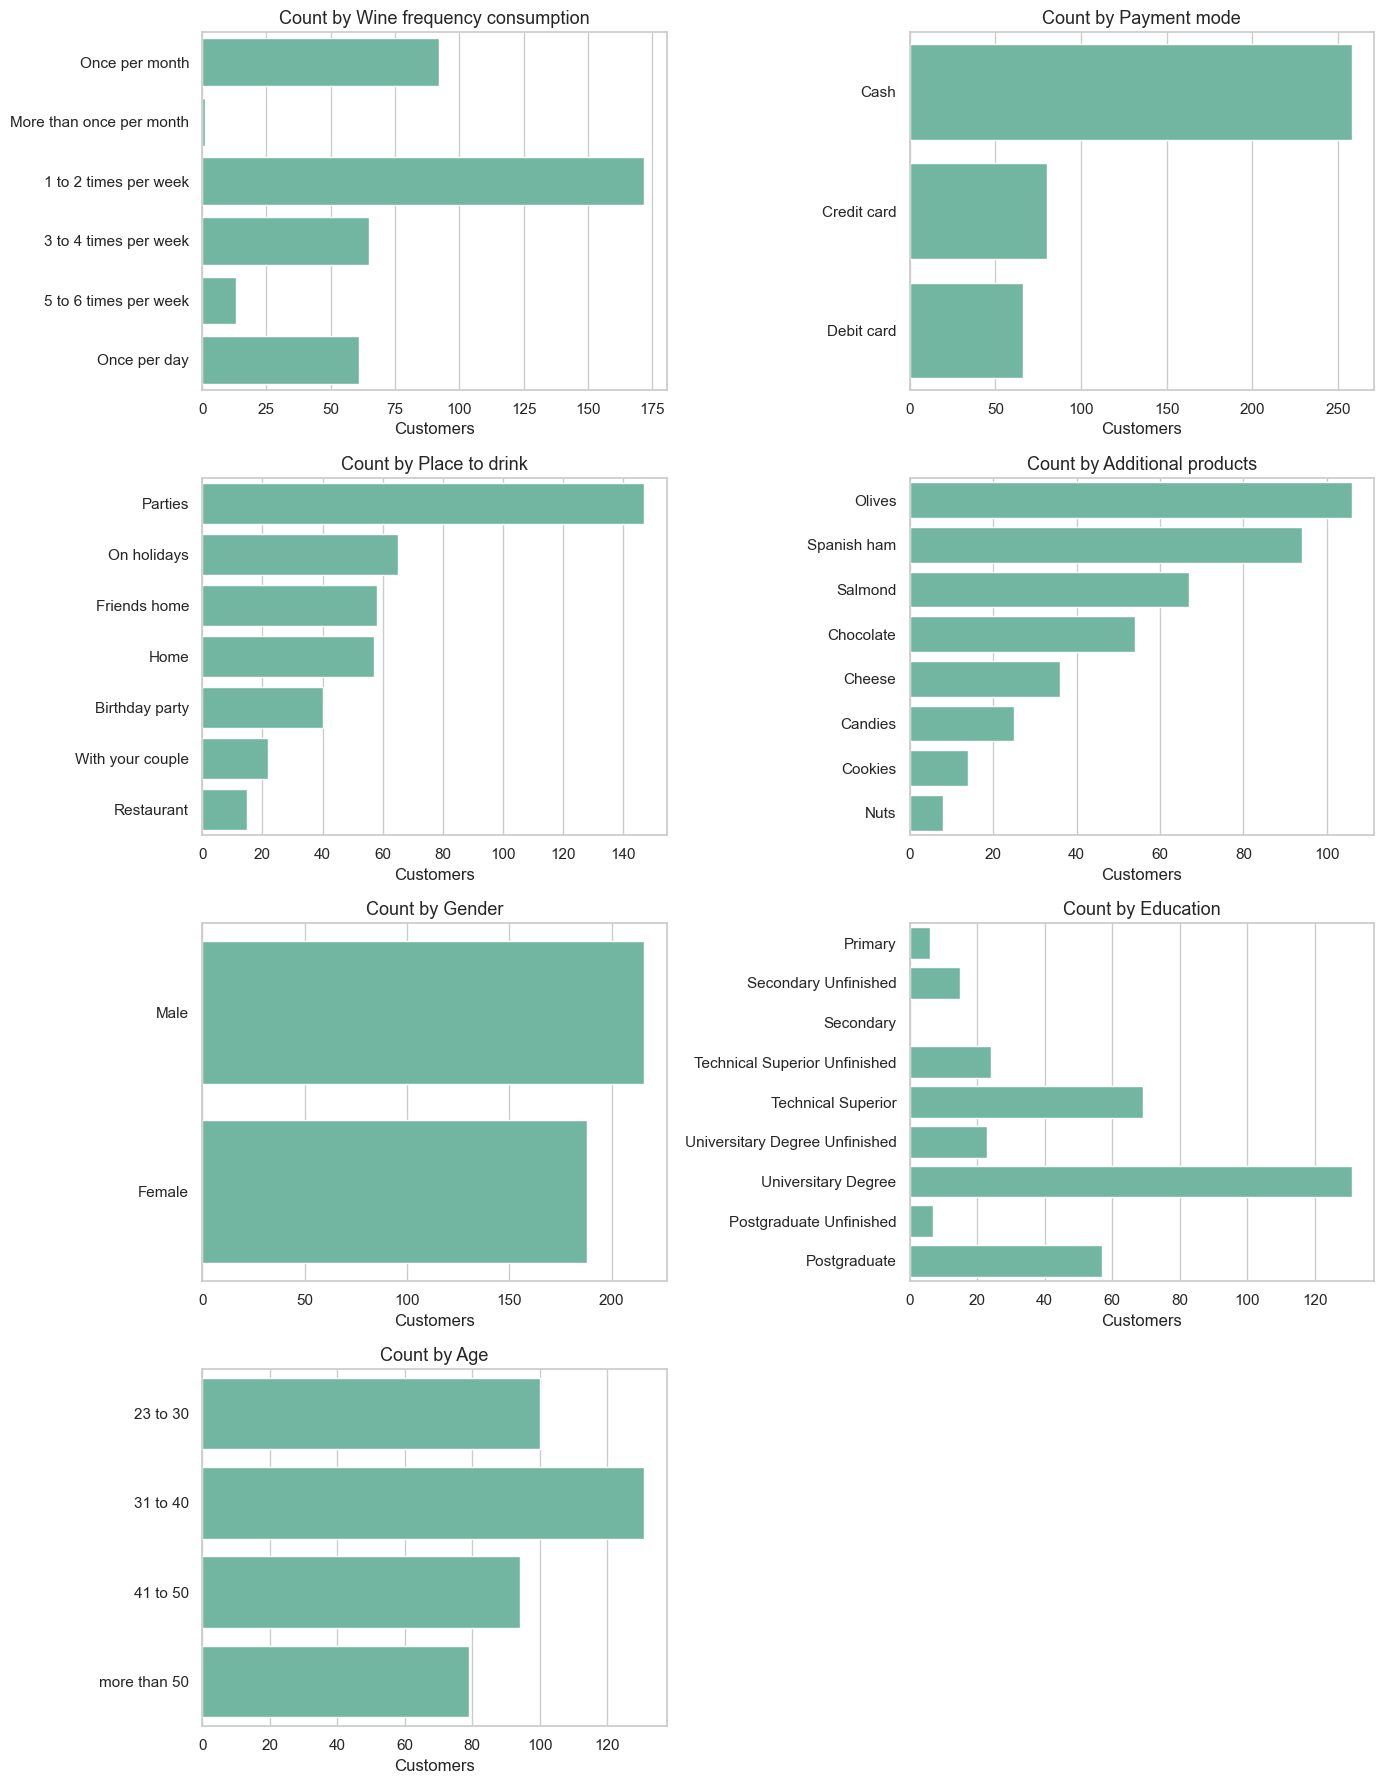

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df[col].cat.categories if hasattr(df[col], 'cat') else df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f'Count by {col}')
    ax.set_xlabel('Customers'); ax.set_ylabel('')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

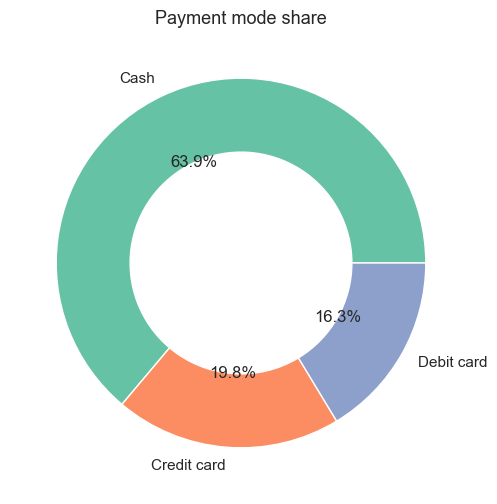

In [5]:
# Donut for payment mode (good for a 3-category share view)
fig, ax = plt.subplots(figsize=(6, 6))
vc = df['Payment mode'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
       wedgeprops=dict(width=0.4), colors=sns.color_palette('Set2'))
ax.set_title('Payment mode share')
plt.show()

## 4. Univariate — Ticket (numeric)

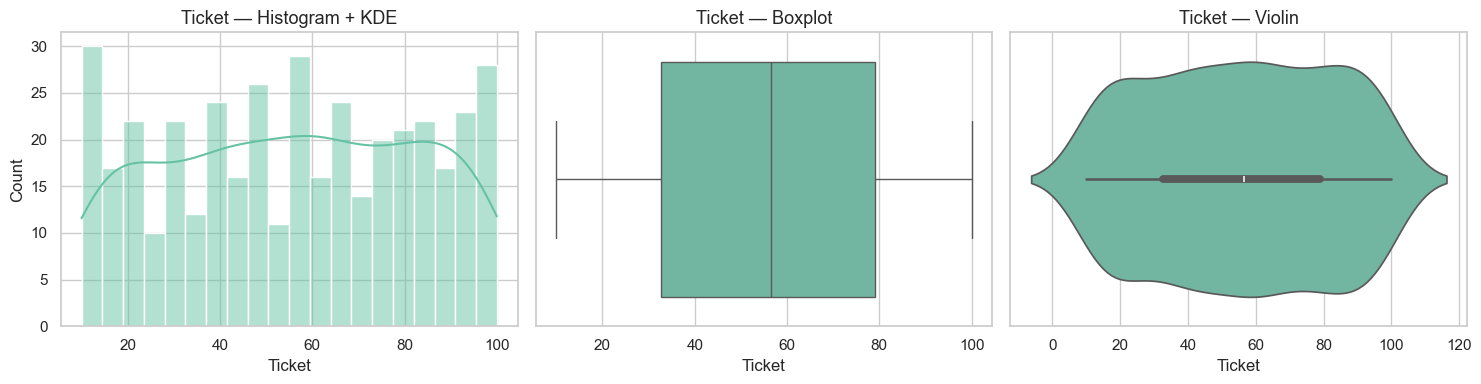

count    404.000000
mean      55.698020
std       26.949966
min       10.000000
25%       32.750000
50%       56.500000
75%       79.000000
max      100.000000
Name: Ticket, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Ticket'], bins=20, kde=True, ax=axes[0]); axes[0].set_title('Ticket — Histogram + KDE')
sns.boxplot(x=df['Ticket'], ax=axes[1]); axes[1].set_title('Ticket — Boxplot')
sns.violinplot(x=df['Ticket'], ax=axes[2]); axes[2].set_title('Ticket — Violin')
plt.tight_layout(); plt.show()
df['Ticket'].describe()

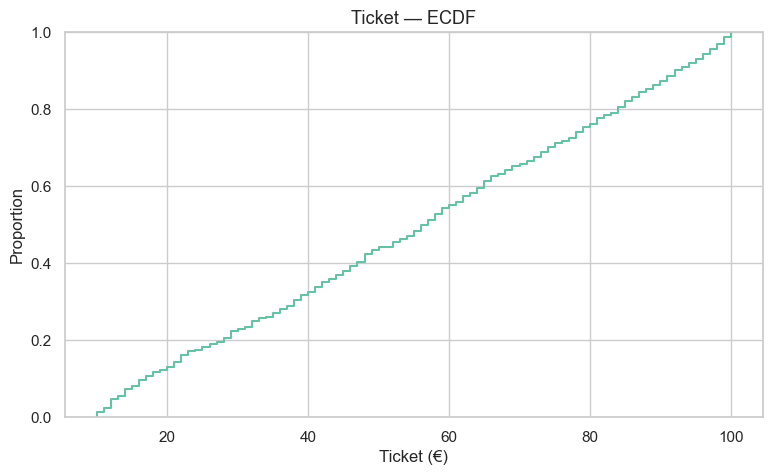

In [7]:
# Empirical CDF — what share of customers spend less than X?
fig, ax = plt.subplots()
sns.ecdfplot(df['Ticket'], ax=ax)
ax.set_title('Ticket — ECDF'); ax.set_xlabel('Ticket (€)')
plt.show()

## 5. Bivariate — Ticket vs each categorical
Where does basket value concentrate?

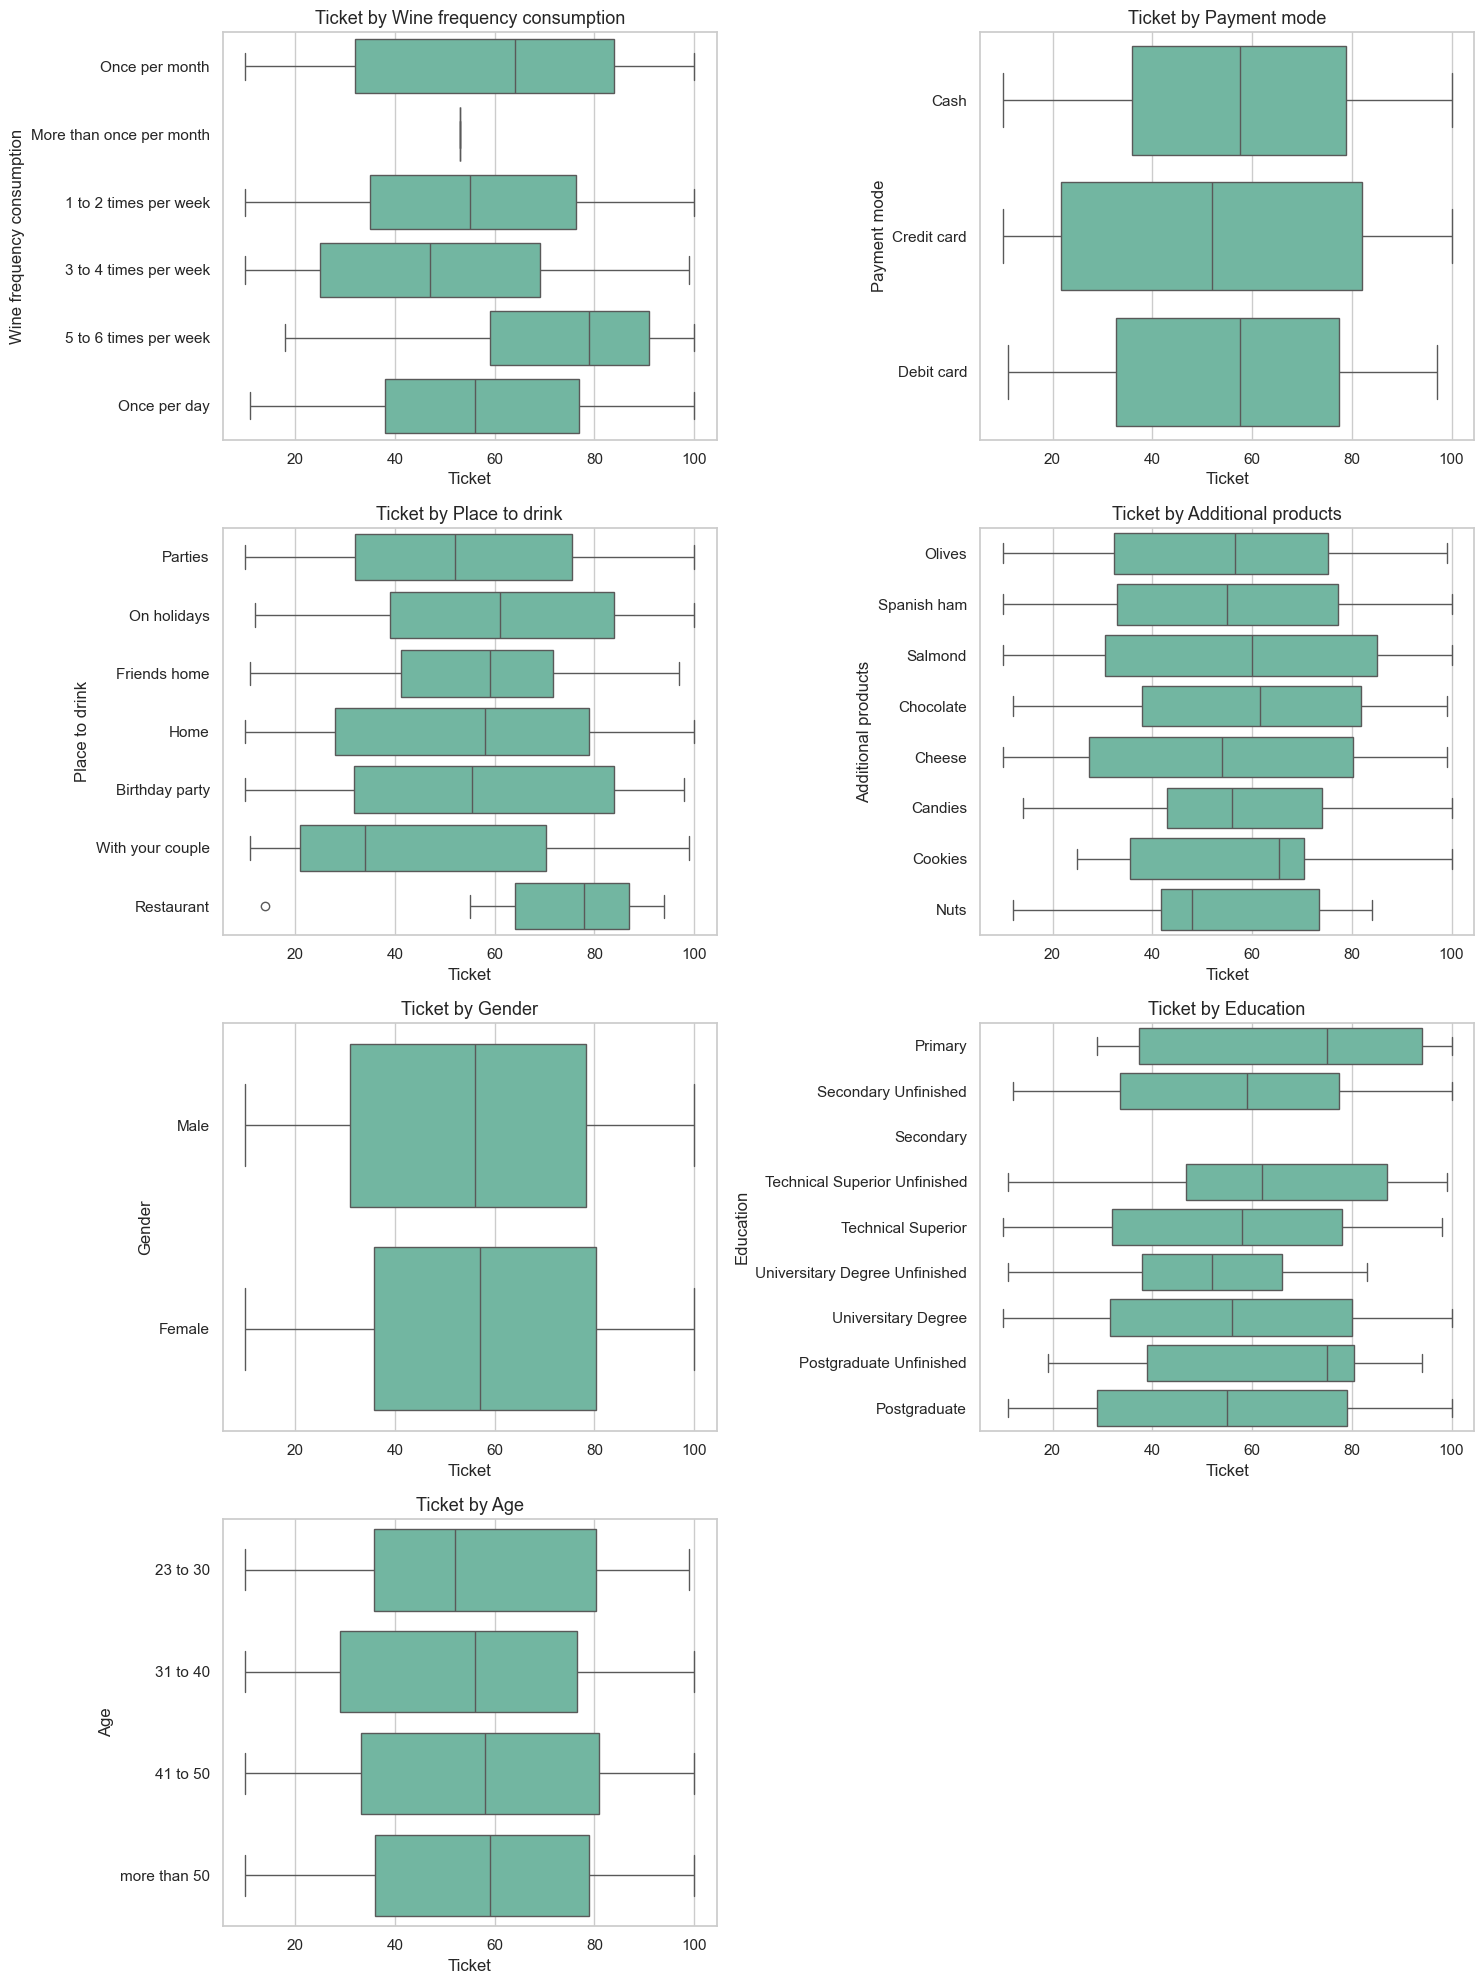

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df[col].cat.categories if hasattr(df[col], 'cat') else df[col].value_counts().index
    sns.boxplot(data=df, y=col, x='Ticket', order=order, ax=ax)
    ax.set_title(f'Ticket by {col}')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

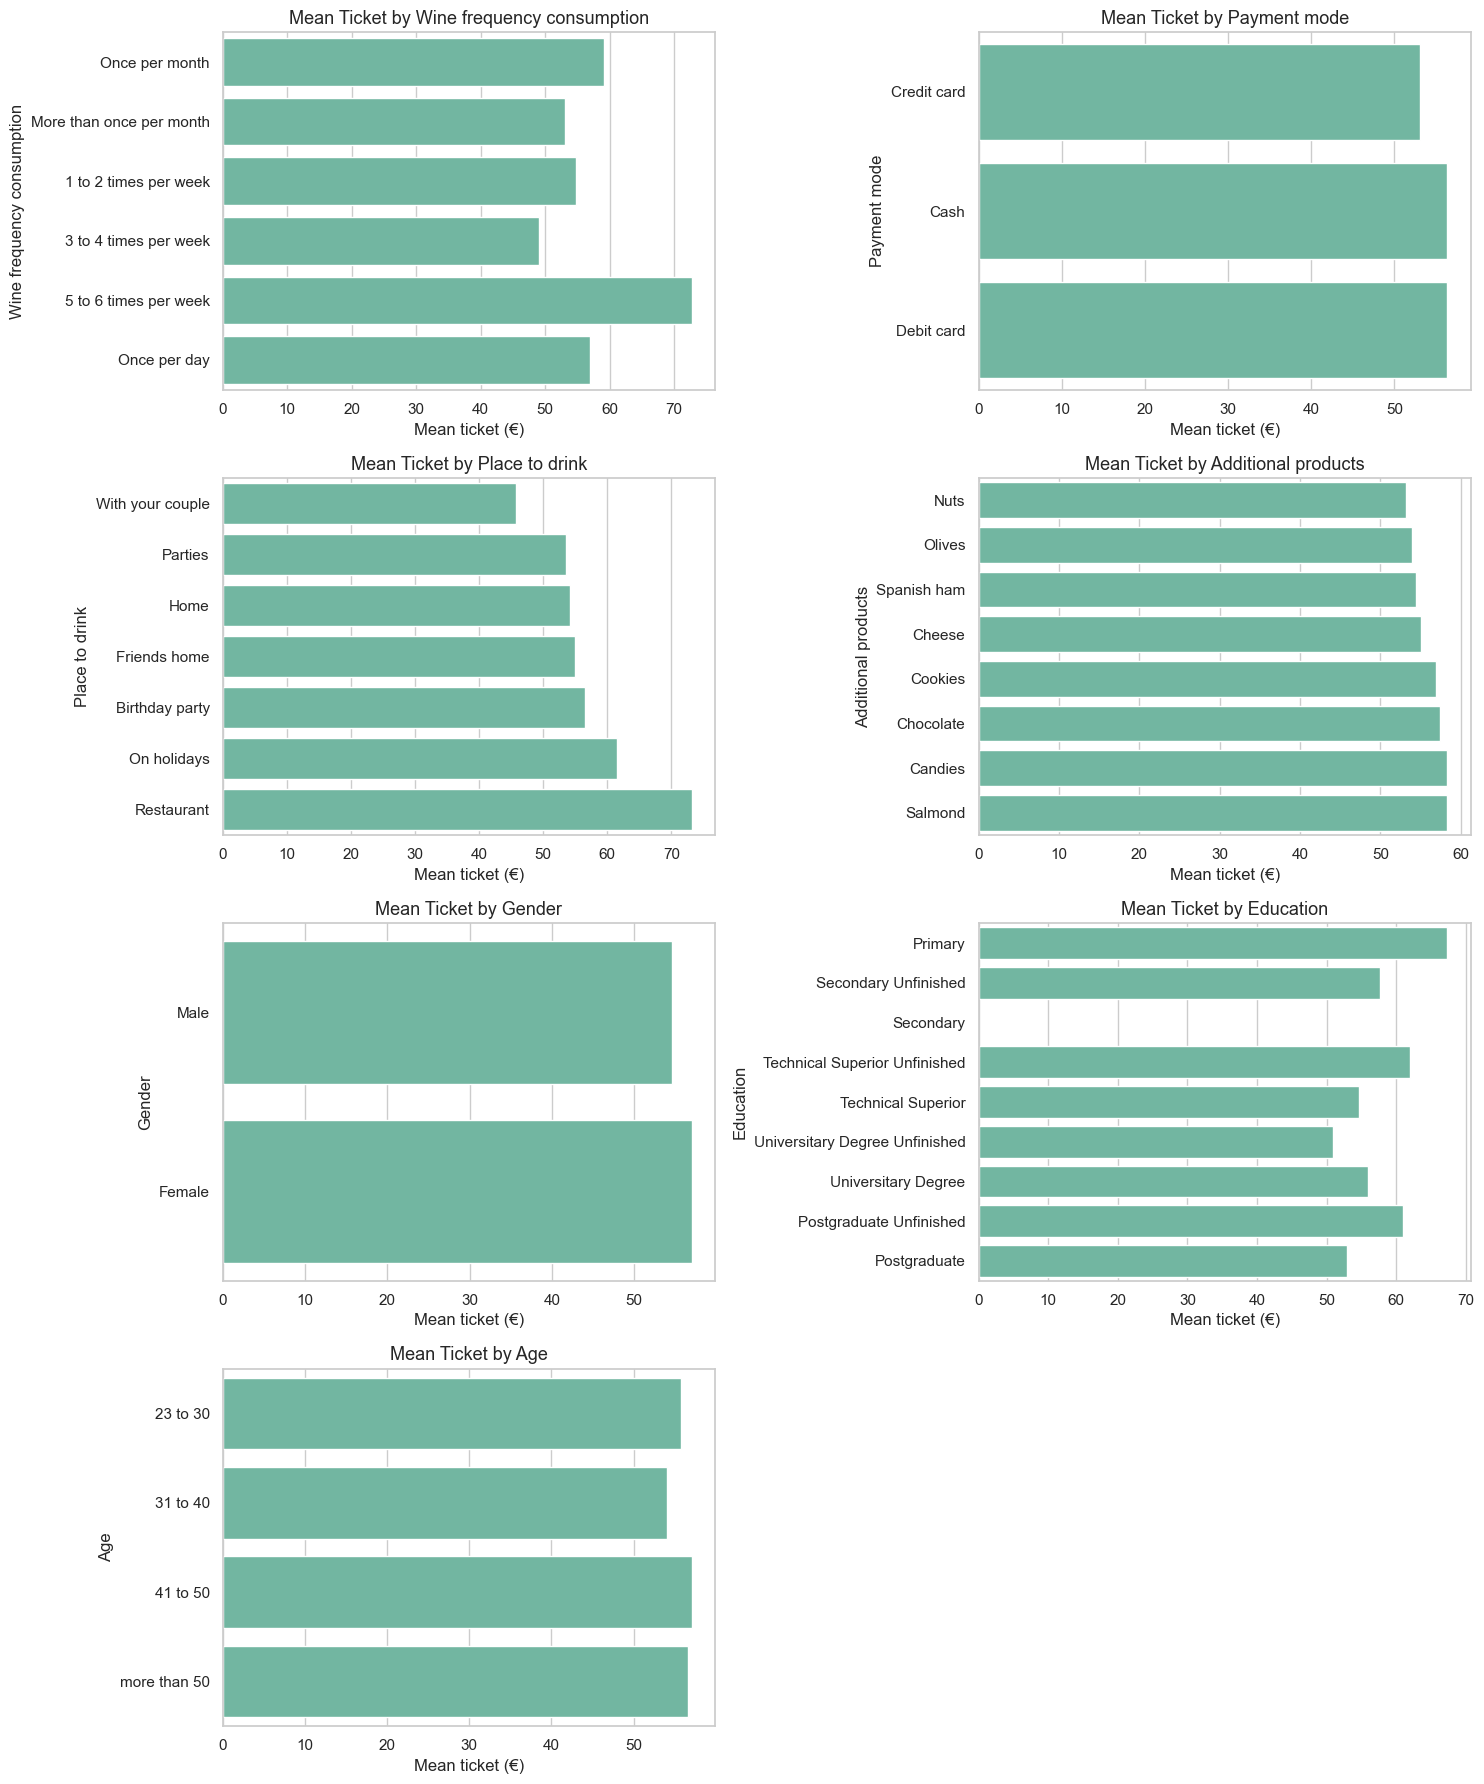

In [9]:
# Mean ticket per category — bar chart version (easier to read for the client report)
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    means = df.groupby(col, observed=True)['Ticket'].mean().sort_values()
    sns.barplot(x=means.values, y=means.index, ax=ax)
    ax.set_title(f'Mean Ticket by {col}')
    ax.set_xlabel('Mean ticket (€)')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

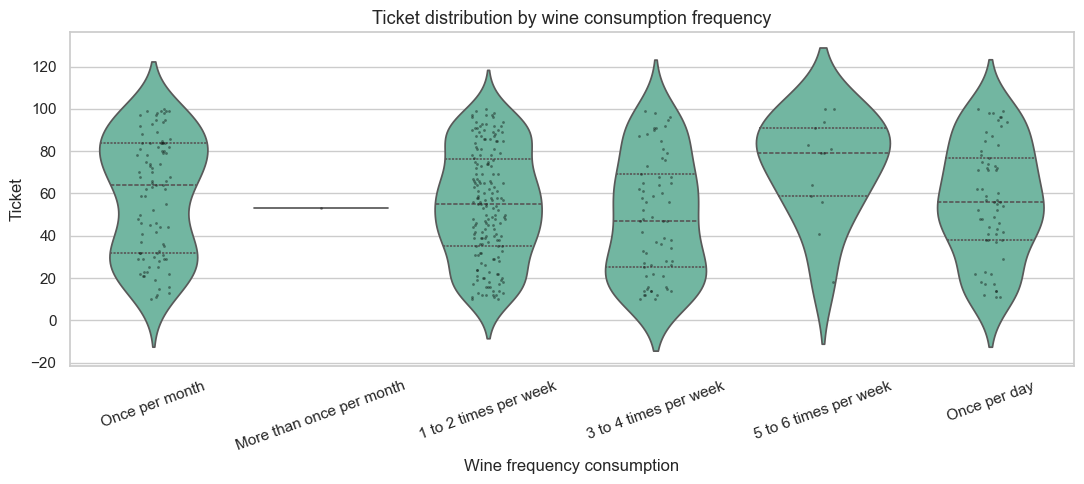

In [10]:
# Strip + violin combo for the most business-relevant split: Ticket by frequency
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=df, x='Wine frequency consumption', y='Ticket',
               order=freq_order, inner='quartile', ax=ax)
sns.stripplot(data=df, x='Wine frequency consumption', y='Ticket',
              order=freq_order, color='black', size=2, alpha=0.4, ax=ax)
ax.set_title('Ticket distribution by wine consumption frequency')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 6. Bivariate — Categorical vs Categorical
Cross-tabs as heatmaps and stacked bars.

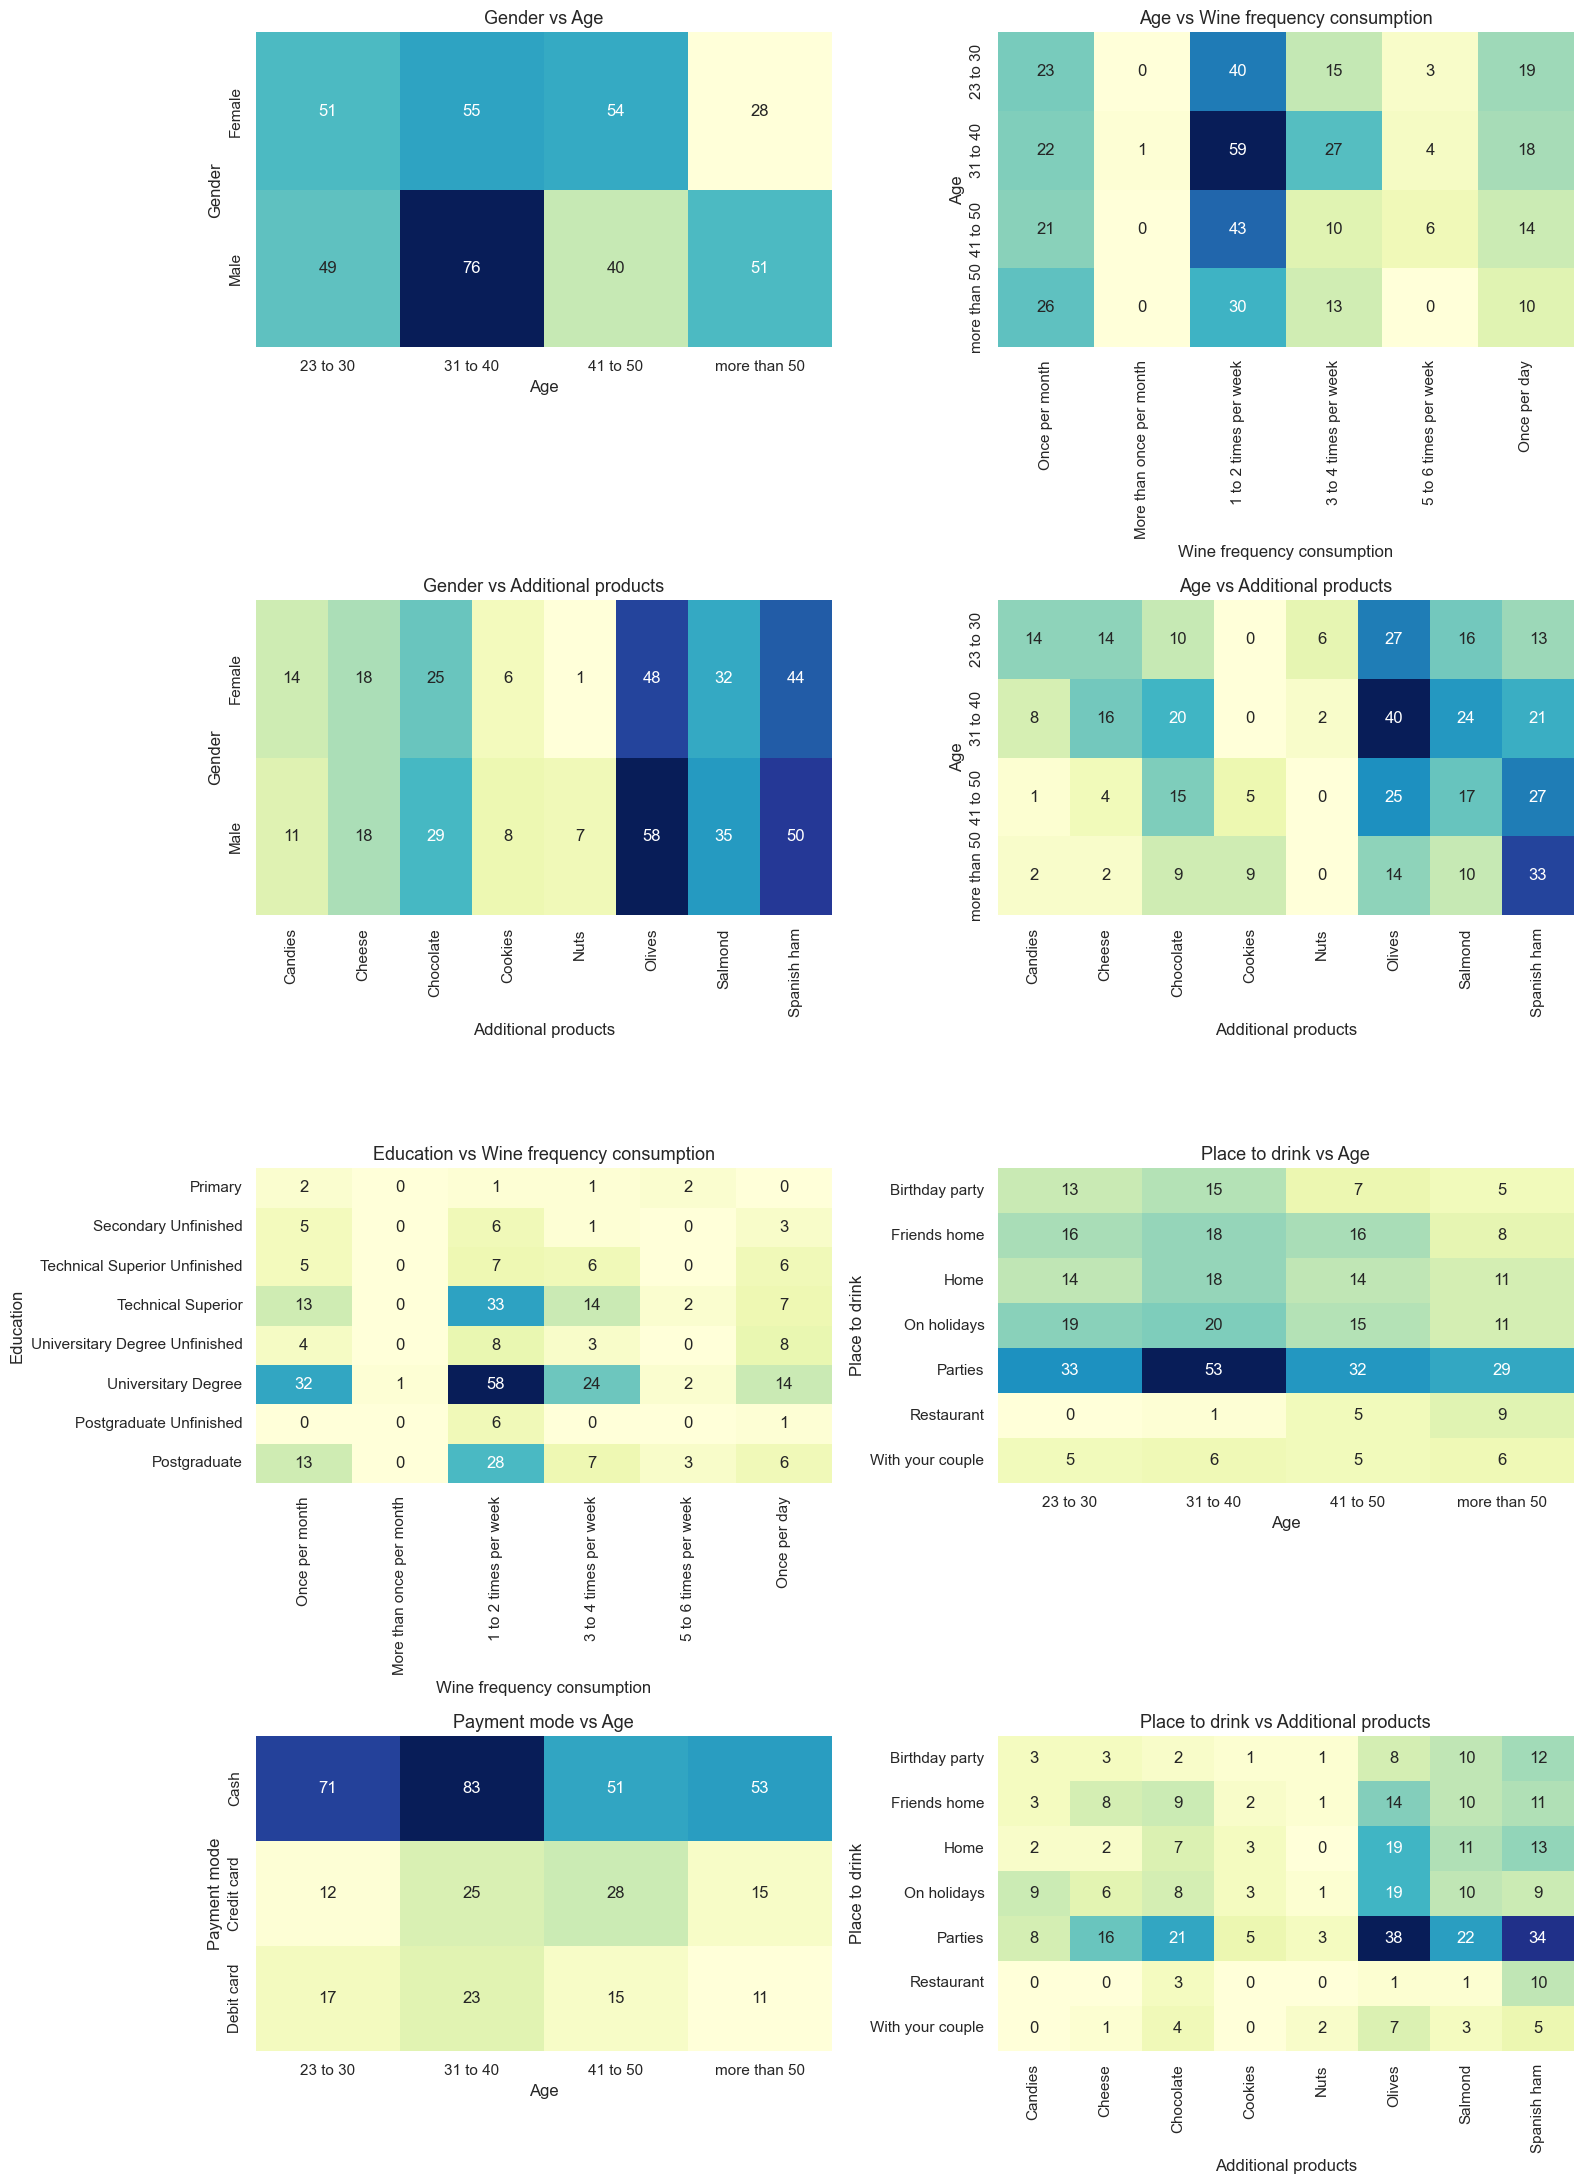

In [11]:
pairs = [
    ('Gender', 'Age'),
    ('Age', 'Wine frequency consumption'),
    ('Gender', 'Additional products'),
    ('Age', 'Additional products'),
    ('Education', 'Wine frequency consumption'),
    ('Place to drink', 'Age'),
    ('Payment mode', 'Age'),
    ('Place to drink', 'Additional products'),
]
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df[a], df[b])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=ax)
    ax.set_title(f'{a} vs {b}')
plt.tight_layout(); plt.show()

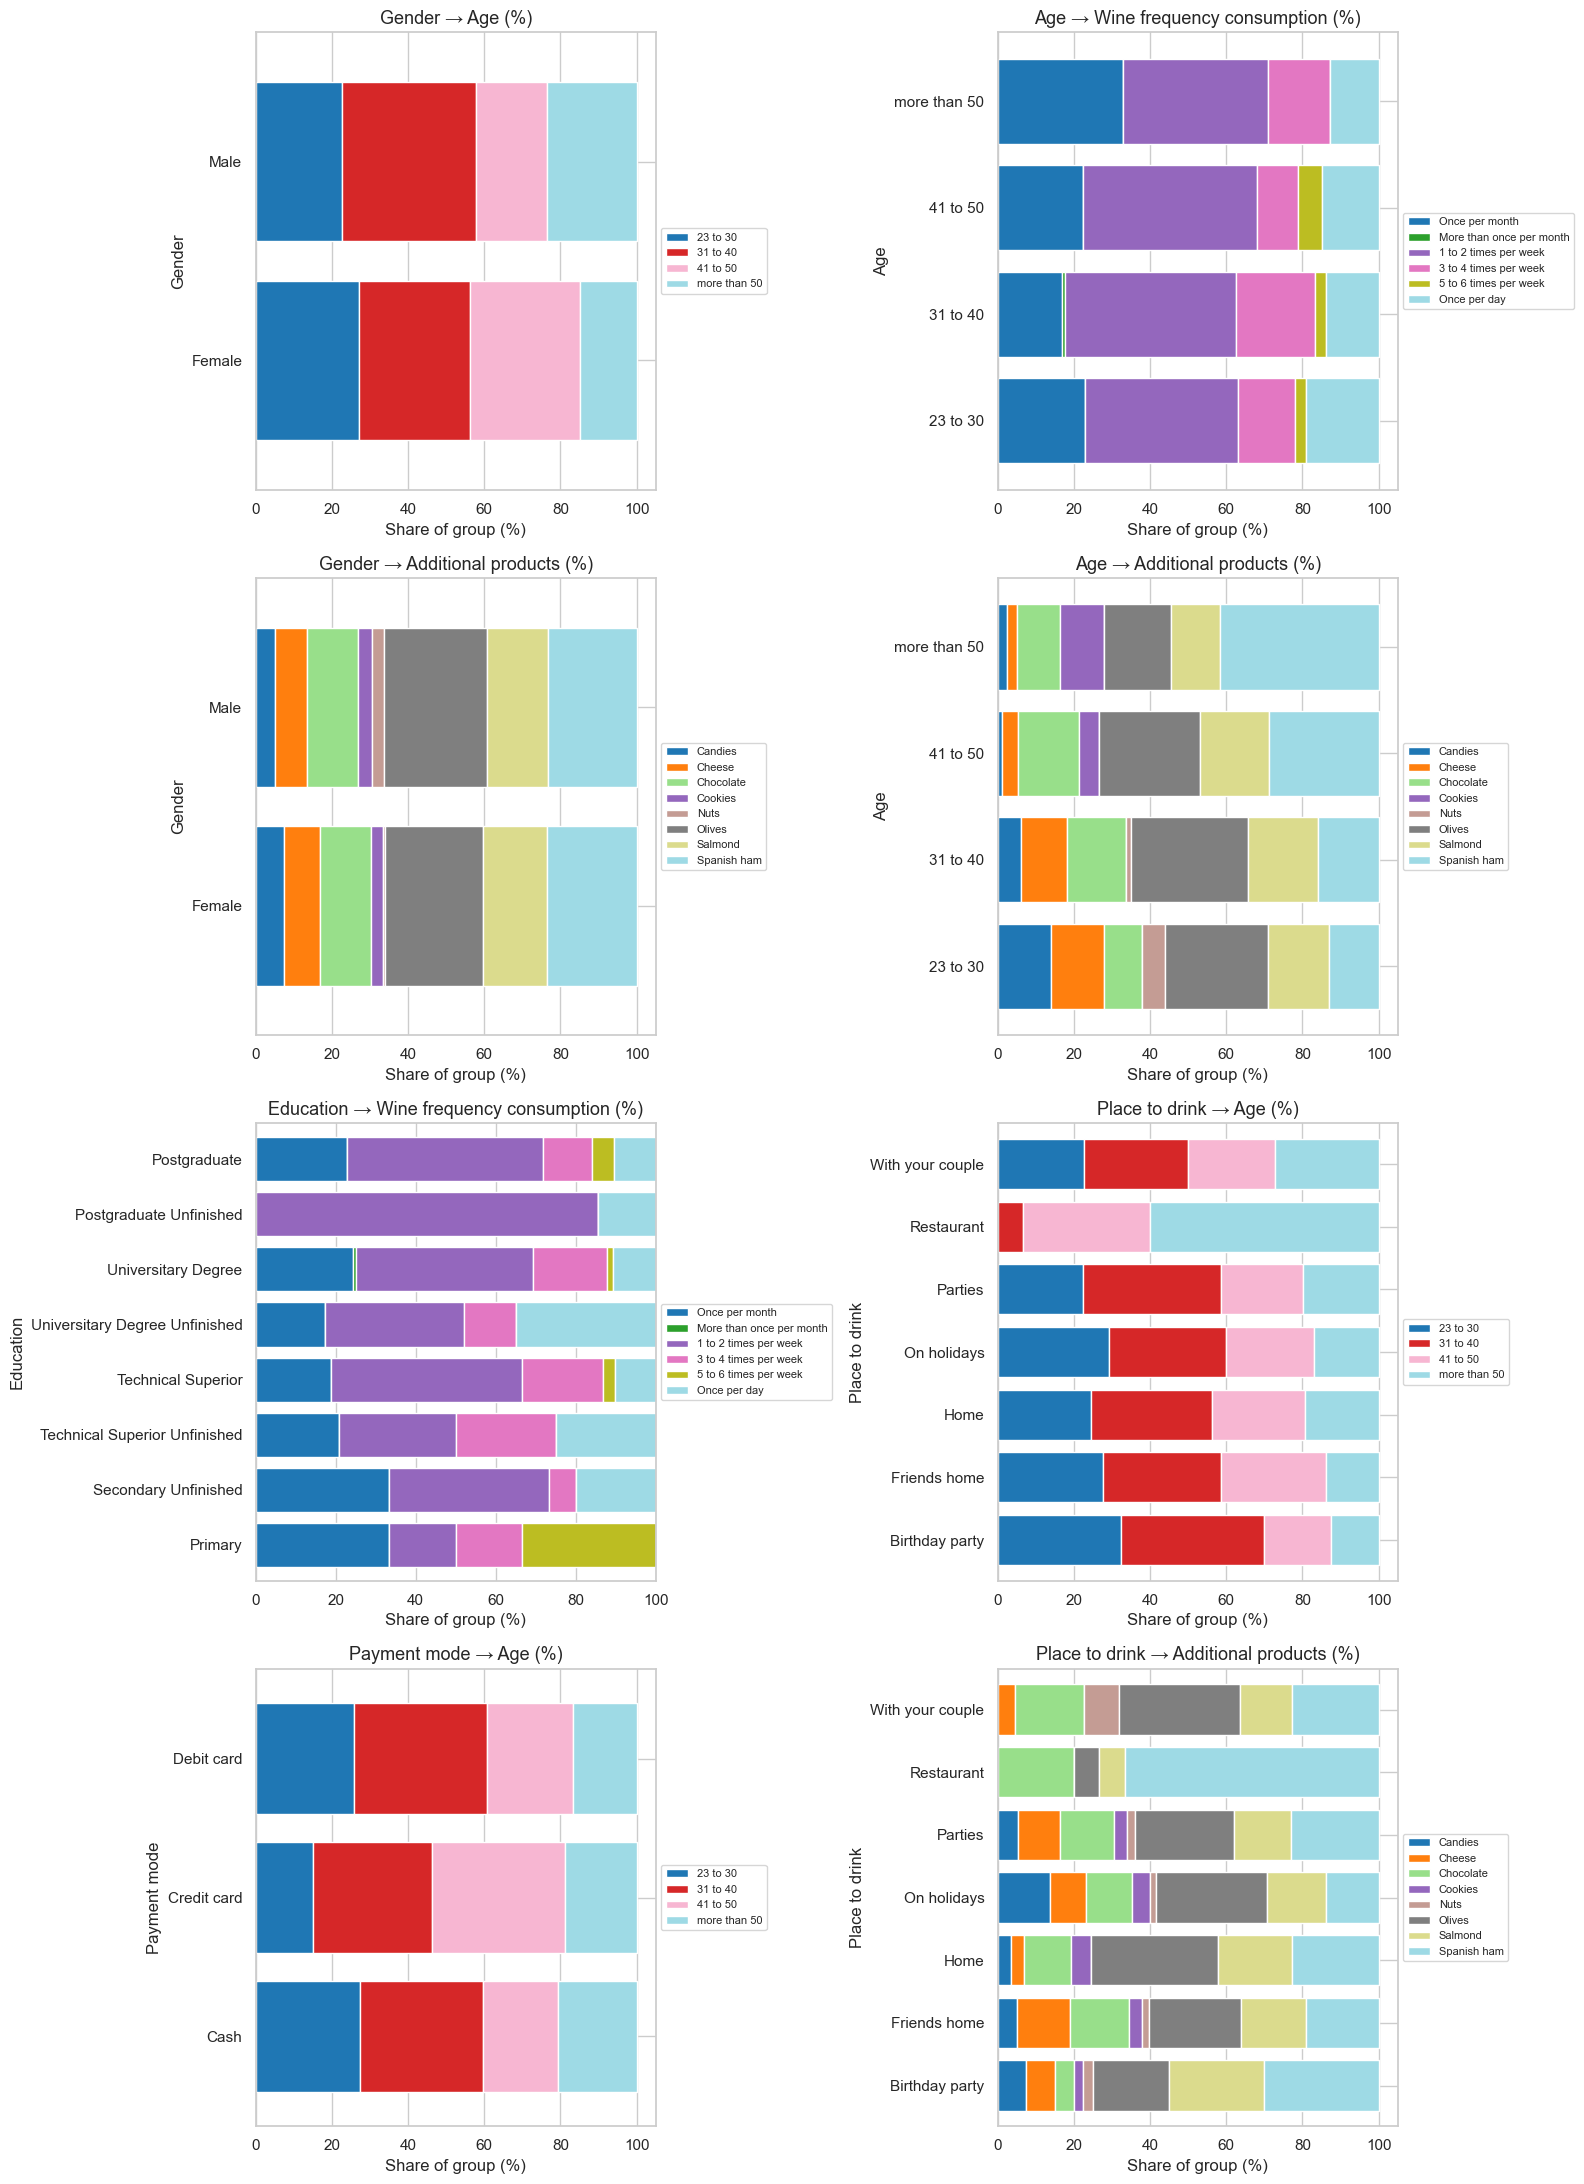

In [12]:
# Same pairs as 100% stacked bars — easier to compare proportions across groups
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
for ax, (a, b) in zip(axes, pairs):
    ct = pd.crosstab(df[a], df[b], normalize='index') * 100
    ct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.8)
    ax.set_title(f'{a} → {b} (%)')
    ax.set_xlabel('Share of group (%)')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

## 7. Multivariate — small multiples
Ticket distribution split by Gender × Age, and grouped means.

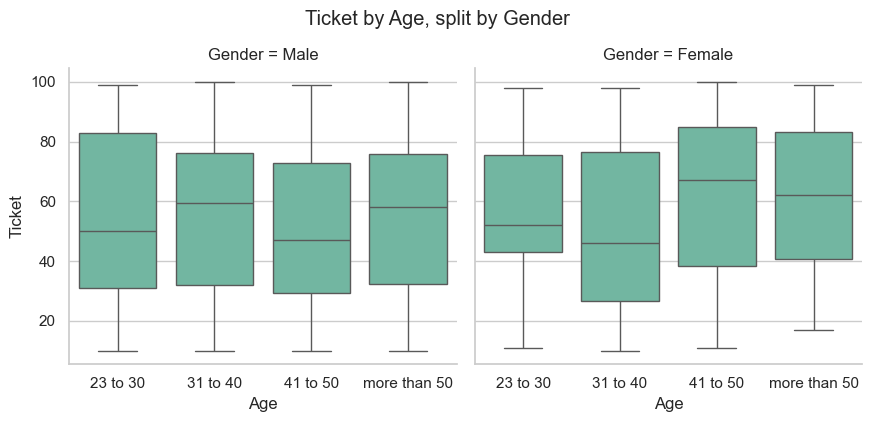

In [13]:
g = sns.catplot(data=df, kind='box', x='Age', y='Ticket', col='Gender',
                order=age_order, height=4, aspect=1.1)
g.fig.suptitle('Ticket by Age, split by Gender', y=1.05)
plt.show()

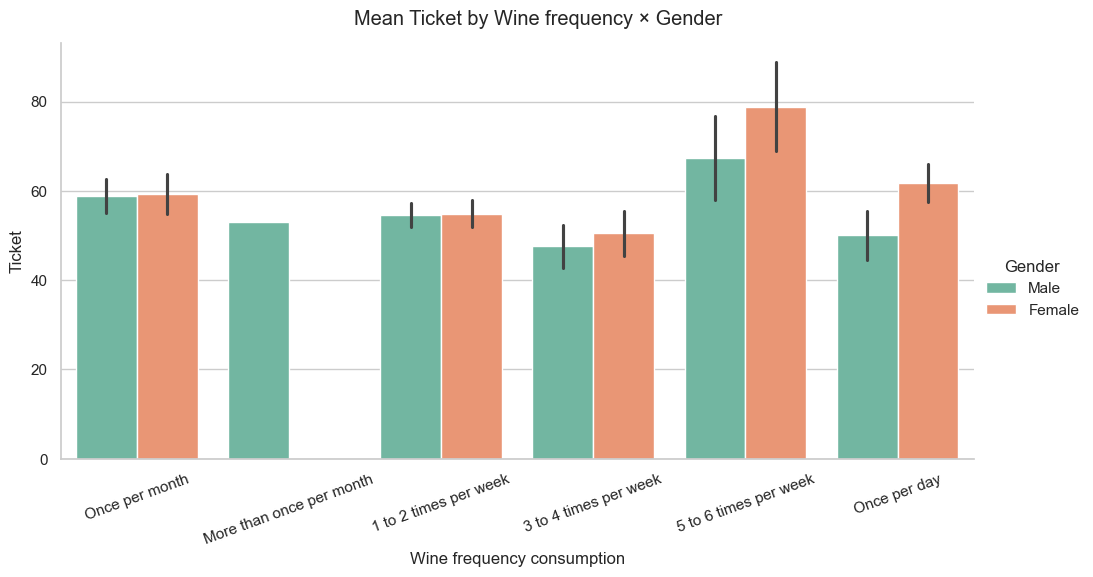

In [14]:
g = sns.catplot(data=df, kind='bar', x='Wine frequency consumption', y='Ticket',
                hue='Gender', order=freq_order, height=5, aspect=2, errorbar='se')
g.set_xticklabels(rotation=20)
g.fig.suptitle('Mean Ticket by Wine frequency × Gender', y=1.03)
plt.show()

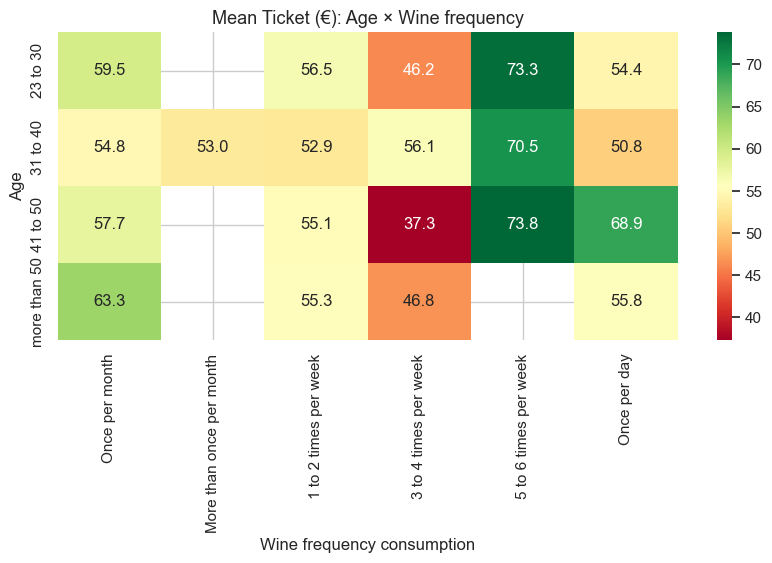

In [15]:
# Heatmap of mean ticket: Age × Wine frequency
pivot = df.pivot_table(index='Age', columns='Wine frequency consumption',
                       values='Ticket', aggfunc='mean', observed=True)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
ax.set_title('Mean Ticket (€): Age × Wine frequency')
plt.show()

## 8. Plotly — interactive visualizations (Session 3 toolkit)
Treemap, sunburst, parallel categories, Sankey-style flows.

In [16]:
# Treemap of additional products, broken down by gender
agg = df.groupby(['Additional products', 'Gender']).size().reset_index(name='count')
fig = px.treemap(agg, path=['Additional products', 'Gender'], values='count',
                 color='count', color_continuous_scale='Teal',
                 title='Additional products bought (treemap)')
fig.show()

In [17]:
# Sunburst: Age → Gender → Place to drink
agg = df.groupby(['Age', 'Gender', 'Place to drink'], observed=True).size().reset_index(name='count')
fig = px.sunburst(agg, path=['Age', 'Gender', 'Place to drink'], values='count',
                  title='Customer profile sunburst — Age → Gender → Place to drink')
fig.show()

In [18]:
# Parallel categories — see how customer profiles flow across categorical dimensions
tmp = df.dropna(subset=['Education']).copy()
tmp['Wine frequency consumption'] = tmp['Wine frequency consumption'].astype(str)
tmp['Age'] = tmp['Age'].astype(str)
fig = px.parallel_categories(
    tmp, dimensions=['Gender', 'Age', 'Wine frequency consumption', 'Payment mode'],
    color='Ticket', color_continuous_scale=px.colors.sequential.Viridis,
    title='Parallel categories — customer profile flow (color = Ticket)')
fig.show()

In [19]:
# Bar of mean ticket per Place to drink, ordered
agg = df.groupby('Place to drink')['Ticket'].agg(['mean', 'count']).reset_index().sort_values('mean')
fig = px.bar(agg, x='mean', y='Place to drink', orientation='h',
             text=agg['count'].apply(lambda x: f'n={x}'),
             title='Mean Ticket by Place to drink', labels={'mean': 'Mean ticket (€)'})
fig.show()

In [20]:
# Strip / scatter view: ticket per individual, colored by frequency, faceted by age
fig = px.strip(df, x='Wine frequency consumption', y='Ticket', color='Gender',
               facet_col='Age', category_orders={'Age': age_order, 'Wine frequency consumption': freq_order},
               title='Ticket per customer — Gender × Wine frequency, faceted by Age')
fig.update_xaxes(tickangle=30)
fig.show()

## 9. Association strength between categorical variables (Cramér's V)
A heatmap of pairwise association — analogue of correlation, but for categoricals.

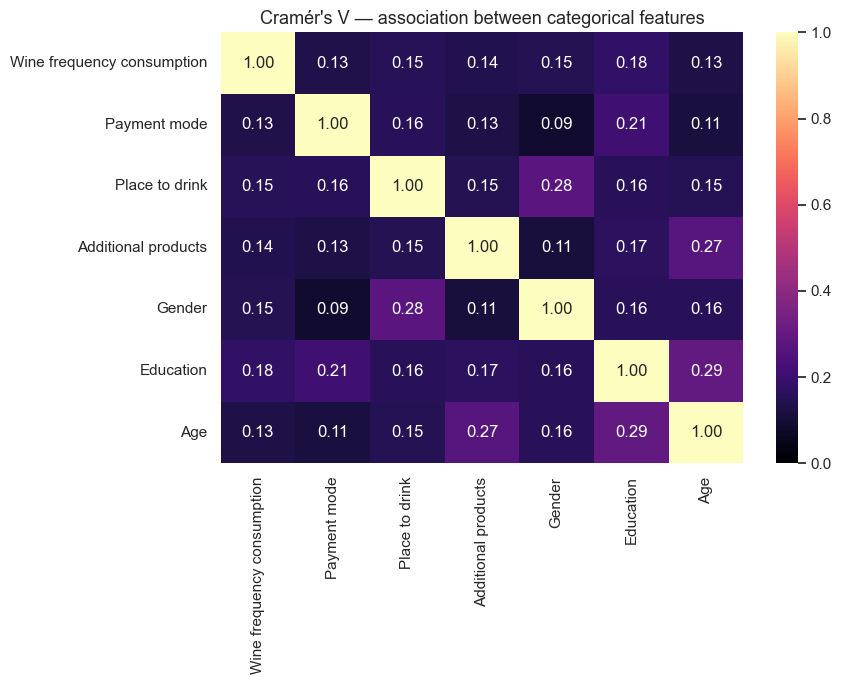

In [21]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.size == 0: return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else np.nan

cats = cat_cols
mat = pd.DataFrame(index=cats, columns=cats, dtype=float)
for a in cats:
    for b in cats:
        mat.loc[a, b] = cramers_v(df[a], df[b])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat.astype(float), annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1, ax=ax)
ax.set_title("Cramér's V — association between categorical features")
plt.tight_layout(); plt.show()

## 10. Headline takeaways (preliminary)
Items to validate in the deeper analysis / report:

1. **Customer base skews 31–50, mostly with higher education.** Marketing copy and channels should reflect that.
2. **Wine is mainly consumed at *parties / holidays / friends' homes*** — social occasions rather than at home alone. Bundles like *wine + olives + Spanish ham* fit this.
3. **Cash dominates payment (~64%)**, even with university-educated customers — point-of-sale and loyalty design should not assume card-first.
4. **Olives and Spanish ham are the top deli add-ons** — these are the natural anchors for cross-sell to fight the "perceived as a wine shop" problem.
5. **Ticket value is broadly uniform (10–100 €, mean ~56 €)** with no extreme outliers — segmentation by ticket size alone is weak; behavioral segments (frequency × occasion × add-on) look more promising.
6. **Cramér's V** flags which categorical pairs deserve a deeper look (e.g. Age ↔ Frequency, Place ↔ Additional product) for the segmentation step.

---

## 11. Dashboard-aligned views

Every chart in the final Streamlit dashboard exists in this section, in the
same order it appears on the *Customer Profile* and *ML Clustering* tabs.
The dashboard relies on three derived columns that need to be computed here
explicitly: `monthly_visits`, `monthly_spend`, and `Education_group`.

### 11.0 Derive the columns the dashboard uses

`monthly_visits` (frequency category → numeric visits/month midpoint),
`monthly_spend` (Ticket × monthly_visits), `Education_group` (collapse the
9 raw levels into 4 marketing-relevant tiers).

In [ ]:
# Frequency → visits/month (midpoint of each verbal band)
FREQ_VISITS_PER_MONTH = {
    'Once per month':            1,
    'More than once per month':  2,
    '1 to 2 times per week':     6,
    '3 to 4 times per week':    14,
    '5 to 6 times per week':    22,
    'Once per day':             30,
}

# 9 source levels → 4 tiers (matches wine_data.py EDUCATION_GROUPS)
EDUCATION_GROUPS = {
    'Primary':                        'Basic',
    'Secondary Unfinished':           'Basic',
    'Secondary':                      'Basic',
    'Technical Superior Unfinished':  'Technical',
    'Technical Superior':             'Technical',
    'Universitary Degree Unfinished': 'University',
    'Universitary Degree':            'University',
    'Postgraduate Unfinished':        'Postgraduate',
    'Postgraduate':                   'Postgraduate',
}
EDUCATION_GROUP_ORDER = ['Basic', 'Technical', 'University', 'Postgraduate']

# Sociality score: 1 = private/alone, 7 = large social gathering
SOCIAL_MAP = {
    'Home':             1,
    'With your couple': 2,
    'Friends home':     3,
    'On holidays':      4,
    'Restaurant':       5,
    'Birthday party':   6,
    'Parties':          7,
}

# Defensive whitespace strip (the source has 'Secondary ' with a trailing space)
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].apply(lambda v: v.strip() if isinstance(v, str) else v)
df['Education'] = df['Education'].replace({1: np.nan, '1': np.nan})

df['monthly_visits']   = df['Wine frequency consumption'].map(FREQ_VISITS_PER_MONTH).fillna(1)
df['monthly_spend']    = df['Ticket'] * df['monthly_visits']
df['est_annual_rev']   = df['monthly_spend'] * 12
df['Education_group']  = df['Education'].map(EDUCATION_GROUPS)
df['social_score']     = df['Place to drink'].map(SOCIAL_MAP).fillna(4)

print(f'Avg monthly spend: €{df["monthly_spend"].mean():.0f}')
print(f'Est annual revenue: €{df["est_annual_rev"].sum()/1000:.0f}K')
print(f'\nEducation tier counts:')
print(df['Education_group'].value_counts().reindex(EDUCATION_GROUP_ORDER))

### 11.1 Population pyramid — Age × Gender

Customer-Profile tab, Section A. Male bars go negative, female bars positive,
so the asymmetries between age bands jump out at a glance.

In [ ]:
AGE_ORDER = ['23 to 30', '31 to 40', '41 to 50', 'more than 50']

pop = (df.pivot_table(index='Age', columns='Gender', aggfunc='size', fill_value=0)
         .reindex(AGE_ORDER))

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(pop))
ax.barh(y, -pop['Male'].values,  color='#7B2D3E', height=0.7, label='Male')
ax.barh(y,  pop['Female'].values, color='#2980B9', height=0.7, label='Female')
ax.axvline(0, color='black', linewidth=0.7)
ax.set_yticks(y); ax.set_yticklabels(pop.index)
for i, (m, f) in enumerate(zip(pop['Male'].values, pop['Female'].values)):
    ax.text(-m - 2, i, str(m), ha='right', va='center', color='#7B2D3E', fontweight='bold')
    ax.text(f + 2,  i, str(f), ha='left',  va='center', color='#2980B9', fontweight='bold')
ax.set_title('Population pyramid — Age × Gender')
ax.legend(loc='lower right', frameon=False)
ax.set_xticks([])
plt.tight_layout(); plt.show()

### 11.2 Education funnel — 4 grouped tiers

Same chart as the dashboard. The grouping (9 raw levels → 4 marketing-relevant
tiers) compresses noise; the original `Education` column is preserved on the
dashboard's Customer Explorer expander (inside the Customer Profile tab).

In [ ]:
counts = (df['Education_group'].dropna().value_counts()
            .reindex(EDUCATION_GROUP_ORDER).fillna(0).astype(int)
            .sort_values(ascending=True))  # largest at top of horizontal bar
pct = (counts / counts.sum() * 100).round(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 3.2))
colors = ['#7B2D3E' if v == counts.max() else '#2980B9' for v in counts]
bars = ax.barh(counts.index, counts.values, color=colors)
for b, c, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_width() + 2, b.get_y() + b.get_height()/2,
            f'{c}  ({p}%)', va='center')
ax.set_title('Education tiers — 4 grouped levels')
ax.set_xlabel('Customers')
ax.set_xlim(0, counts.max() * 1.25)
plt.tight_layout(); plt.show()

### 11.3 Diverging bars — where customers drink, split by gender

The strongest behavioral signal in the dataset. Sorting by male/female skew
exposes the cells that drive in-store display + bundle decisions.

In [ ]:
ct = pd.crosstab(df['Place to drink'], df['Gender'])
ct['total'] = ct['Male'] + ct['Female']
ct['m_pct'] = ct['Male']   / ct['total']
ct['f_pct'] = ct['Female'] / ct['total']
ct = ct.sort_values('m_pct')

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(ct))
ax.barh(y, -ct['Male'].values,  color='#7B2D3E', height=0.7, label='Male')
ax.barh(y,  ct['Female'].values, color='#2980B9', height=0.7, label='Female')
ax.axvline(0, color='black', linewidth=0.7)
ax.set_yticks(y); ax.set_yticklabels(ct.index)
mx = max(ct['Male'].max(), ct['Female'].max())
for i, (m, f, t) in enumerate(zip(ct['Male'], ct['Female'], ct['total'])):
    ax.text(-m - mx*0.02, i, f'{m} ({m/t*100:.0f}%)', ha='right', va='center', fontsize=9)
    ax.text( f + mx*0.02, i, f'{f} ({f/t*100:.0f}%)', ha='left',  va='center', fontsize=9)
ax.set_title('Where customers drink — diverging by gender')
ax.legend(loc='lower right', frameon=False)
ax.set_xticks([])
plt.tight_layout(); plt.show()

print('Top male-skewed:')
for p in ct.sort_values('m_pct', ascending=False).head(3).index:
    print(f'  {ct.loc[p, "m_pct"]*100:.0f}% Male in "{p}"')
print('Top female-skewed:')
for p in ct.sort_values('f_pct', ascending=False).head(2).index:
    print(f'  {ct.loc[p, "f_pct"]*100:.0f}% Female in "{p}"')

### 11.4 Monthly-spending heatmaps — the three views from the dashboard

`monthly_spend = Ticket × monthly_visits` is the headline KPI: a daily €20
drinker (€600/mo) is more valuable than a once-a-month €80 drinker (€80/mo).
Per-visit ticket would have hidden a 7× difference between these two profiles.

Three views are useful: Gender × Education (gives the counter-intuitive
'Female × Basic = €850/mo' finding), Age × Education (life-stage × class),
and Age × Occasion (the marketing-actionable matrix).

In [ ]:
import matplotlib.colors as mcolors
WINE_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'wine', ['#F5EEE4', '#D4872A', '#7B2D3E']
)

def spending_heatmap(work, row, col, row_order, col_order, ax, title):
    means = (work.pivot_table(values='monthly_spend', index=row,
                              columns=col, aggfunc='mean')
                 .reindex(index=row_order, columns=col_order))
    counts = (work.pivot_table(values='monthly_spend', index=row,
                               columns=col, aggfunc='count')
                  .reindex(index=row_order, columns=col_order))
    im = ax.imshow(means.values, cmap=WINE_CMAP, aspect='auto', vmin=0)
    ax.set_xticks(range(len(means.columns)))
    ax.set_xticklabels(means.columns, rotation=20, ha='right', fontsize=8)
    ax.set_yticks(range(len(means.index)))
    ax.set_yticklabels(means.index, fontsize=9)
    for i in range(means.shape[0]):
        for j in range(means.shape[1]):
            v = means.values[i, j]
            c = counts.values[i, j]
            if not np.isnan(v):
                color = 'white' if v > np.nanmean(means.values) else 'black'
                ax.text(j, i, f'€{int(round(v))}\n(n={int(c)})',
                        ha='center', va='center', fontsize=7.5, color=color)
    ax.set_title(title)

work = df.dropna(subset=['Education_group'])

# 3 heatmaps in a figure
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
spending_heatmap(work, 'Gender', 'Education_group',
                 ['Female','Male'], EDUCATION_GROUP_ORDER, axes[0],
                 'Avg monthly spend · Gender × Education tier')
spending_heatmap(work, 'Age', 'Education_group',
                 AGE_ORDER, EDUCATION_GROUP_ORDER, axes[1],
                 'Avg monthly spend · Age × Education tier')
place_order = sorted(SOCIAL_MAP, key=SOCIAL_MAP.get)
spending_heatmap(work, 'Age', 'Place to drink',
                 AGE_ORDER, place_order, axes[2],
                 'Avg monthly spend · Age × Drinking occasion (marketing-actionable matrix)')
plt.tight_layout(); plt.show()

# Print the headline cells
ge = work.groupby(['Gender','Education_group'], observed=True)['monthly_spend'].mean()
print(f'\nGender × Edu — highest cell: {ge.idxmax()} = €{int(round(ge.max()))}/mo')
print(f'Gender × Edu — lowest cell:  {ge.idxmin()} = €{int(round(ge.min()))}/mo  ← counter-intuitive')

### 11.5 Cramér's V — ranked bar of top categorical pairs

Same statistic as the heatmap in Section 9, but presented as a sorted
horizontal bar. The dashboard uses this ranked view because it surfaces
the takeaway in one glance (which pair is strongest) — a heatmap forces the
eye to scan all 42 cells.

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))

cats = ['Gender', 'Age', 'Education_group', 'Wine frequency consumption',
        'Place to drink', 'Additional products', 'Payment mode']
short = {'Wine frequency consumption': 'Frequency', 'Place to drink': 'Occasion',
         'Additional products': 'Deli product', 'Education_group': 'Education',
         'Payment mode': 'Payment'}

pairs = []
for i, a in enumerate(cats):
    for b in cats[i+1:]:
        v = cramers_v(work[a], work[b]) * 100  # 0-100 scale
        pairs.append((f'{short.get(a, a)} × {short.get(b, b)}', v))
pairs.sort(key=lambda p: -p[1])

top10 = pairs[:10][::-1]  # reversed so strongest sits at top of bar
labels = [p[0] for p in top10]
values = [p[1] for p in top10]
mxv = max(values)
colors = ['#7B2D3E' if v == mxv else '#2980B9' for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, color=colors)
for b, v in zip(bars, values):
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height()/2,
            f'{v:.0f}', va='center', fontweight='bold')
ax.set_title('Top 10 hidden patterns — Cramér\'s V × 100')
ax.set_xlabel('Pattern score (0 = unrelated, 100 = perfectly linked)')
ax.set_xlim(0, mxv * 1.20)
plt.tight_layout(); plt.show()

### 11.6 FM (Frequency × Monetary) segmentation — the revenue lens

Supervised median split on `monthly_visits` × `Ticket`. Produces four named
personas the marketing team can act on directly.

In [ ]:
f_med = df['monthly_visits'].median()
m_med = df['Ticket'].median()
df['F_tier'] = np.where(df['monthly_visits'] >= f_med, 'High', 'Low')
df['M_tier'] = np.where(df['Ticket']         >= m_med, 'High', 'Low')
fm_mapping = {
    ('High','High'): 'Champions',
    ('High','Low'):  'Loyal Regulars',
    ('Low','High'):  'Occasion Splurgers',
    ('Low','Low'):   'Casual Visitors',
}
df['FM_segment'] = df.apply(lambda r: fm_mapping[(r['F_tier'], r['M_tier'])], axis=1)

print('FM segment counts:')
print(df['FM_segment'].value_counts())

SEG_COLORS = {
    'Champions':          '#B5303F',
    'Loyal Regulars':     '#2980B9',
    'Occasion Splurgers': '#D4872A',
    'Casual Visitors':    '#4E7C59',
}
fig, ax = plt.subplots(figsize=(9, 5))
for seg in ['Champions','Loyal Regulars','Occasion Splurgers','Casual Visitors']:
    sub = df[df['FM_segment'] == seg]
    ax.scatter(sub['monthly_visits'], sub['Ticket'], s=30, alpha=0.7,
               color=SEG_COLORS[seg], label=seg, edgecolors='white', linewidth=0.5)
ax.axhline(m_med, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(f_med, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel('Visits / month'); ax.set_ylabel('Avg ticket (€)')
ax.set_title('FM quadrant — every dot is one customer')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# Revenue contribution per segment
rev = df.groupby('FM_segment')['est_annual_rev'].sum().sort_values()
rev_pct = (rev / rev.sum() * 100).round(0).astype(int)
print('\nRevenue contribution:')
for s, p in zip(rev.index, rev_pct.values):
    print(f'  {s:<22} {p}%')

### 11.7 Behavioral K-Means (Lucas's lens) — how customers buy

Unsupervised K-Means K=4 on (`monthly_visits`, `social_score`). Ticket is
*deliberately excluded* so the segments are independent of how much customers
pay. The result: four lifestyle archetypes.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

FEATURES = ['monthly_visits', 'social_score']
X = StandardScaler().fit_transform(df[FEATURES])
labels = KMeans(n_clusters=4, n_init=15, random_state=42).fit_predict(X)

df_b = df.copy()
df_b['beh_id'] = labels

# Name each cluster by its (freq, sociality) profile
means = df_b.groupby('beh_id')[FEATURES].mean()
freq_rank = means['monthly_visits'].rank()
soc_rank  = means['social_score'].rank()
def archetype(idx):
    hi_f = freq_rank[idx] > 2; hi_s = soc_rank[idx] > 2
    if   hi_f and hi_s:     return 'Social Regulars'
    elif hi_f and not hi_s: return 'Daily Home Drinkers'
    elif hi_s and not hi_f: return 'Occasion Celebrants'
    else:                   return 'Casual Home Drinkers'
df_b['beh_segment'] = df_b['beh_id'].apply(archetype)

# Scatter with jitter (both axes are discrete-ish)
rng = np.random.default_rng(42)
df_p = df_b.copy()
df_p['vj'] = df_b['monthly_visits'] + rng.uniform(-0.4, 0.4, len(df_b))
df_p['sj'] = df_b['social_score']   + rng.uniform(-0.25, 0.25, len(df_b))

BEH_COLORS = {'Social Regulars': '#B5303F', 'Daily Home Drinkers': '#2980B9',
              'Occasion Celebrants': '#D4872A', 'Casual Home Drinkers': '#4E7C59'}

fig, ax = plt.subplots(figsize=(9, 5))
for seg, c in BEH_COLORS.items():
    sub = df_p[df_p['beh_segment'] == seg]
    ax.scatter(sub['vj'], sub['sj'], s=28, alpha=0.65, color=c, label=seg,
               edgecolors='white', linewidth=0.4)
ax.set_xlabel('Visits / month (jittered)')
ax.set_ylabel('Sociality score (1 = home, 7 = parties · jittered)')
ax.set_title('Behavioral K-Means K=4 · ticket NOT used')
ax.legend(frameon=False, loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print('Behavioral segment counts:')
print(df_b['beh_segment'].value_counts())

### 11.8 K-Prototypes spend tiers — the value lens

Unsupervised mixed-type clustering on the full feature set: Hamming distance
on six categorical attributes, Euclidean distance on Ticket. Default K=3
produces Entry / Core / Premium Buyers.

This is the *value-anchored* sanity check on the FM segmentation. If
K-Prototypes mostly rediscovers FM's high-ticket quadrants, that confirms
ticket is the primary differentiator in the data.

If the `kmodes` package isn't available, the cell falls back to K-Means on
one-hot encoded data — distorts categorical distances but still useful as a
directional view.

In [ ]:
CAT_COLS = ['Wine frequency consumption', 'Payment mode', 'Place to drink',
            'Additional products', 'Gender', 'Age']
NUM_COLS = ['Ticket']

try:
    from kmodes.kprototypes import KPrototypes
    work2 = df[CAT_COLS + NUM_COLS].copy()
    for c in CAT_COLS:
        work2[c] = work2[c].astype(str).fillna('Unknown')
    cat_idx = [work2.columns.get_loc(c) for c in CAT_COLS]
    model = KPrototypes(n_clusters=3, init='Cao', n_init=5,
                        random_state=42, verbose=0)
    labels_kp = model.fit_predict(work2.values, categorical=cat_idx)
    algo = 'K-Prototypes'
except ImportError:
    print('kmodes not installed — falling back to K-Means on one-hot encoded data.')
    X_cat = pd.get_dummies(df[CAT_COLS].astype(str))
    X_num = StandardScaler().fit_transform(df[NUM_COLS])
    Xm = np.hstack([X_cat.values, X_num])
    labels_kp = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(Xm)
    algo = 'K-Means (fallback)'

df_kp = df.copy()
df_kp['spend_id'] = labels_kp

# Name tiers by avg Ticket: lowest = Entry, middle = Core, highest = Premium
order = df_kp.groupby('spend_id')['Ticket'].mean().sort_values().index.tolist()
tier_names = dict(zip(order, ['Entry Buyers', 'Core Buyers', 'Premium Buyers']))
df_kp['spend_tier'] = df_kp['spend_id'].map(tier_names)

# Summary
csum = df_kp.groupby('spend_tier').agg(
    Customers=('spend_id', 'count'),
    Avg_ticket=('Ticket', 'mean'),
    Avg_visits=('monthly_visits', 'mean'),
).round(1).reindex(['Entry Buyers','Core Buyers','Premium Buyers'])
print(f'Algorithm: {algo}')
print(csum)

# Scatter on freq × ticket
TIER_COLORS = {'Entry Buyers': '#4E7C59', 'Core Buyers': '#D4872A',
               'Premium Buyers': '#7B2D3E'}
fig, ax = plt.subplots(figsize=(9, 5))
for t, c in TIER_COLORS.items():
    sub = df_kp[df_kp['spend_tier'] == t]
    ax.scatter(sub['monthly_visits'], sub['Ticket'], s=30, alpha=0.7,
               color=c, label=t, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Visits / month'); ax.set_ylabel('Avg ticket (€)')
ax.set_title('K-Prototypes spend tiers projected onto Frequency × Ticket')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

# FM × spend-tier cross-tab (does spend tier validate FM?)
ct_fm_kp = pd.crosstab(df_kp['FM_segment'], df_kp['spend_tier'])
ct_fm_kp = ct_fm_kp.reindex(index=['Champions','Loyal Regulars','Occasion Splurgers','Casual Visitors'],
                            columns=['Entry Buyers','Core Buyers','Premium Buyers'],
                            fill_value=0)
print('\nFM segment × Spend tier cross-tab:')
print(ct_fm_kp)

---

## 12. Closing notes

This notebook documents every chart that made it into the final Streamlit
dashboard. The dashboard adds interactivity (filters, sliders, the What-If
revenue simulator), but the underlying analytical content matches what's
above.

Updated to match the dashboard's restructured repo: data lives at
`../data/wine_consumption_survey.xlsx`, Python source at `../app/`, and
this notebook lives in `../notebooks/`.